In [1]:
import pandas as pd
import numpy as np

In [2]:
df_ball=pd.read_csv('/content/IPL Ball-by-Ball 2008-2020 - IPL Ball-by-Ball 2008-2020.csv')
df_match=pd.read_csv('/content/IPL Matches 2008-2020 - IPL Matches 2008-2020.csv')


In [3]:
df_ball.shape

(193468, 18)

In [4]:
df_match.shape

(816, 17)

In [5]:
df_ball.head()

,id,inning,over,ball,batsman,non_striker,bowler,batsman_runs,extra_runs,total_runs,non_boundary,is_wicket,dismissal_kind,player_dismissed,fielder,extras_type,batting_team,bowling_team
0,335982,1,6,5,RT Ponting,BB McCullum,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
1,335982,1,6,6,BB McCullum,RT Ponting,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
2,335982,1,7,1,BB McCullum,RT Ponting,Z Khan,0,0,0,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
3,335982,1,7,2,BB McCullum,RT Ponting,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
4,335982,1,7,3,RT Ponting,BB McCullum,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore


In [6]:
df_match.head()

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2
0,335982,Bangalore,4/18/2008,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,Chandigarh,4/19/2008,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",0,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,N,NaN,MR Benson,SL Shastri
2,335984,Delhi,4/19/2008,MF Maharoof,Feroz Shah Kotla,0,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,Mumbai,4/20/2008,MV Boucher,Wankhede Stadium,0,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,N,NaN,SJ Davis,DJ Harper
4,335986,Kolkata,4/20/2008,DJ Hussey,Eden Gardens,0,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,N,NaN,BF Bowden,K Hariharan


In [7]:
df=pd.merge(df_ball,df_match,on='id')

In [8]:
df.head()

,id,inning,over,ball,batsman,non_striker,bowler,batsman_runs,extra_runs,total_runs,...,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2
0,335982,1,6,5,RT Ponting,BB McCullum,AA Noffke,1,0,1,...,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen
1,335982,1,6,6,BB McCullum,RT Ponting,AA Noffke,1,0,1,...,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen
2,335982,1,7,1,BB McCullum,RT Ponting,Z Khan,0,0,0,...,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen
3,335982,1,7,2,BB McCullum,RT Ponting,Z Khan,1,0,1,...,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen
4,335982,1,7,3,RT Ponting,BB McCullum,Z Khan,1,0,1,...,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen


In [9]:
df.shape

(193468, 34)

In [10]:
df.columns

Index(['id', 'inning', 'over', 'ball', 'batsman', 'non_striker', 'bowler',
       'batsman_runs', 'extra_runs', 'total_runs', 'non_boundary', 'is_wicket',
       'dismissal_kind', 'player_dismissed', 'fielder', 'extras_type',
       'batting_team', 'bowling_team', 'city', 'date', 'player_of_match',
       'venue', 'neutral_venue', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'winner', 'result', 'result_margin', 'eliminator',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

In [11]:
df.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).nlargest(5)

,batsman_runs
batsman,
V Kohli,5878
SK Raina,5368
DA Warner,5254
RG Sharma,5230
S Dhawan,5197


In [12]:
df['dismissal_kind'].unique()

array([nan, 'caught', 'run out', 'bowled', 'lbw', 'retired hurt',
       'stumped', 'caught and bowled', 'hit wicket',
       'obstructing the field'], dtype=object)

In [13]:
valid=[ 'caught', 'run out', 'bowled', 'lbw', 'retired hurt',
       'stumped', 'caught and bowled', 'hit wicket',
       'obstructing the field']
bowlers=df[df['dismissal_kind'].isin(valid)]
bowlers['dismissal_kind'].value_counts()

,count
dismissal_kind,
caught,5743
bowled,1700
run out,893
lbw,571
stumped,294
caught and bowled,269
hit wicket,12
retired hurt,11
obstructing the field,2


In [14]:
bowlers.groupby('bowler')['is_wicket'].sum().sort_values(ascending=False).idxmax()

'SL Malinga'

In [15]:
#Orange cap winner in 2008
df['date']=pd.to_datetime(df['date'],format='mixed')
df[df['date'].dt.year==2008].groupby('batsman')['batsman_runs'].sum().nlargest(1)

,batsman_runs
batsman,
SE Marsh,616


In [16]:
bowlers=df[(df['dismissal_kind'].isin(valid))  & (df['date'].dt.year==2008)]
bowlers.groupby('bowler')['is_wicket'].sum().nlargest(1)

,is_wicket
bowler,
Sohail Tanvir,24


In [17]:
df['date'].dt.year.unique()

array([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,
       2019, 2020], dtype=int32)

In [18]:
year=[2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,
       2019, 2020]
for i in year:
  bowlers=df[(df['dismissal_kind'].isin(valid))  & (df['date'].dt.year==i)]
  print(bowlers.groupby('bowler')['is_wicket'].sum().nlargest(1))


bowler
Sohail Tanvir    24
Name: is_wicket, dtype: int64
bowler
RP Singh    26
Name: is_wicket, dtype: int64
bowler
PP Ojha    22
Name: is_wicket, dtype: int64
bowler
SL Malinga    30
Name: is_wicket, dtype: int64
bowler
M Morkel    30
Name: is_wicket, dtype: int64
bowler
DJ Bravo    34
Name: is_wicket, dtype: int64
bowler
MM Sharma    26
Name: is_wicket, dtype: int64
bowler
DJ Bravo    28
Name: is_wicket, dtype: int64
bowler
B Kumar    24
Name: is_wicket, dtype: int64
bowler
B Kumar    28
Name: is_wicket, dtype: int64
bowler
AJ Tye    28
Name: is_wicket, dtype: int64
bowler
K Rabada    28
Name: is_wicket, dtype: int64
bowler
K Rabada    30
Name: is_wicket, dtype: int64


In [19]:
df1=df.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).nlargest(5)
df1.shape

(5,)

In [20]:
df1=pd.DataFrame(df1)
df1.reset_index(inplace=True)
df1

,batsman,batsman_runs
0,V Kohli,5878
1,SK Raina,5368
2,DA Warner,5254
3,RG Sharma,5230
4,S Dhawan,5197


In [21]:
x=df1['batsman']
y=df1['batsman_runs'].astype(int)

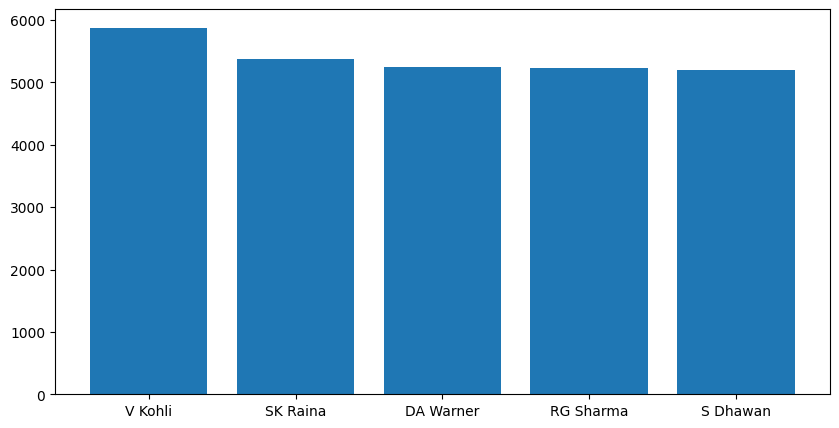

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.bar(x,y)
plt.show()